# Avaliação da qualidade de um processo de classificação de grãos de feijão por meio de CEP e Machine Learning

Maria Eduarda Lobo Montenegro. Matrícula 200033972
Universidade de Brasília. Departamento de Engenharia de Produção
Disciplina de Controle Estatístico de Processos
Prof. Andre Luiz Marques Serrano
Abril de 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/melobomontenegro-dev/CEP_Projeto_Maria_Eduarda/blob/main/avaliacao_qualidade_graos.ipynb)

## Configuração do ambiente

In [1]:
!pip install -q ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             f1_score, precision_score, recall_score)
from ucimlrepo import fetch_ucirepo
import warnings
warnings.filterwarnings('ignore')

# Paleta de cores da UnB
UNB_VERDE = '#006633'
UNB_AZUL = '#003366'
UNB_AREIA = '#d9d2b6'
PALETA_UNB = [UNB_VERDE, UNB_AZUL, '#8a9a5b', '#4a6b3a', '#5b7c99', '#2c4a6b', '#736b3f']

from matplotlib.colors import LinearSegmentedColormap
CMAP_UNB = LinearSegmentedColormap.from_list(
    'unb_divergent', [UNB_AZUL, '#ffffff', UNB_VERDE], N=256
)
CMAP_UNB_SEQ = LinearSegmentedColormap.from_list(
    'unb_sequential', ['#ffffff', UNB_VERDE, '#003322'], N=256
)

# Tipografia mais academica
sns.set_style('white')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.edgecolor'] = '#4a4a4a'
plt.rcParams['axes.labelcolor'] = '#2c2c2c'
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = ':'

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 130)
np.random.seed(42)

## 1. Carregamento do dataset

Carrego o conjunto de dados diretamente do UCI Repository pelo pacote `ucimlrepo`. Essa escolha torna o trabalho reproduzível por qualquer pessoa que execute o notebook, sem necessidade de arquivos locais.

In [3]:
dry_bean = fetch_ucirepo(id=602)
X_full = dry_bean.data.features
y_full = dry_bean.data.targets
df = pd.concat([X_full, y_full], axis=1)
target_col = y_full.columns[0]

print(f'Dataset: {df.shape[0]} amostras, {df.shape[1]} colunas')
print(f'Variedades distintas: {df[target_col].nunique()}')
print(f'Valores ausentes: {df.isnull().sum().sum()}')

Dataset: 13611 amostras, 17 colunas
Variedades distintas: 7
Valores ausentes: 0


## 2. Análise exploratória

Antes de qualquer análise mais elaborada, faço uma inspeção da estrutura: distribuição das classes, estatísticas descritivas e correlações entre features.

In [4]:
# Distribuicao da target
contagem = df[target_col].value_counts()
proporcao = (contagem / len(df) * 100).round(2)
dist = pd.DataFrame({'Amostras': contagem, 'Proporcao (%)': proporcao})
print(dist)
print(f'\nTotal: {len(df)} | Razao max/min: {contagem.max()/contagem.min():.2f}x')

          Amostras  Proporcao (%)
Class                            
DERMASON      3546          26.05
SIRA          2636          19.37
SEKER         2027          14.89
HOROZ         1928          14.17
CALI          1630          11.98
BARBUNYA      1322           9.71
BOMBAY         522           3.84

Total: 13611 | Razao max/min: 6.79x


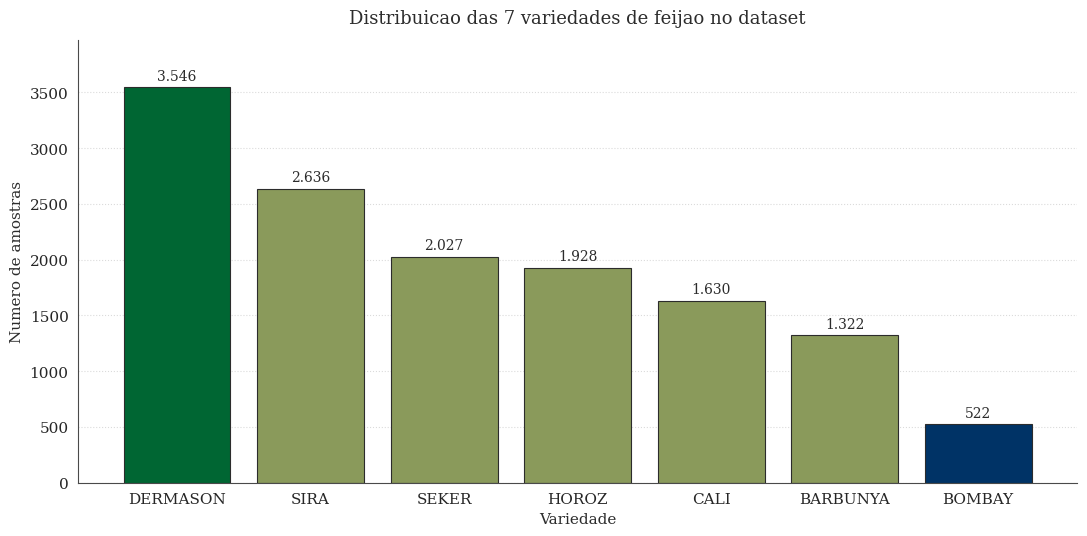

In [5]:
# Grafico 1: distribuicao das variedades
fig, ax = plt.subplots(figsize=(11, 5.5))
cores = [UNB_VERDE if c == contagem.idxmax() else
         UNB_AZUL if c == contagem.idxmin() else '#8a9a5b'
         for c in contagem.index]
barras = ax.bar(contagem.index, contagem.values, color=cores, edgecolor='#2c2c2c', linewidth=0.8)
for barra, valor in zip(barras, contagem.values):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 40,
            f'{valor:,}'.replace(',', '.'),
            ha='center', va='bottom', fontsize=10, color='#2c2c2c')
ax.set_title('Distribuicao das 7 variedades de feijao no dataset',
             fontsize=13, color='#2c2c2c', pad=12)
ax.set_xlabel('Variedade'); ax.set_ylabel('Numero de amostras')
ax.set_ylim(0, contagem.max() * 1.12)
ax.grid(axis='y', color='#888')
plt.tight_layout(); plt.show()

DERMASON aparece com 26% das amostras, BOMBAY com apenas 3,8%, uma razão de cerca de 7×. Esse desbalanceamento não exige técnicas pesadas como SMOTE, mas é suficiente para tornar acurácia uma métrica enganosa. Adoto **F1-macro** como métrica principal a partir daqui, conforme discutido nas aulas de avaliação de modelos.

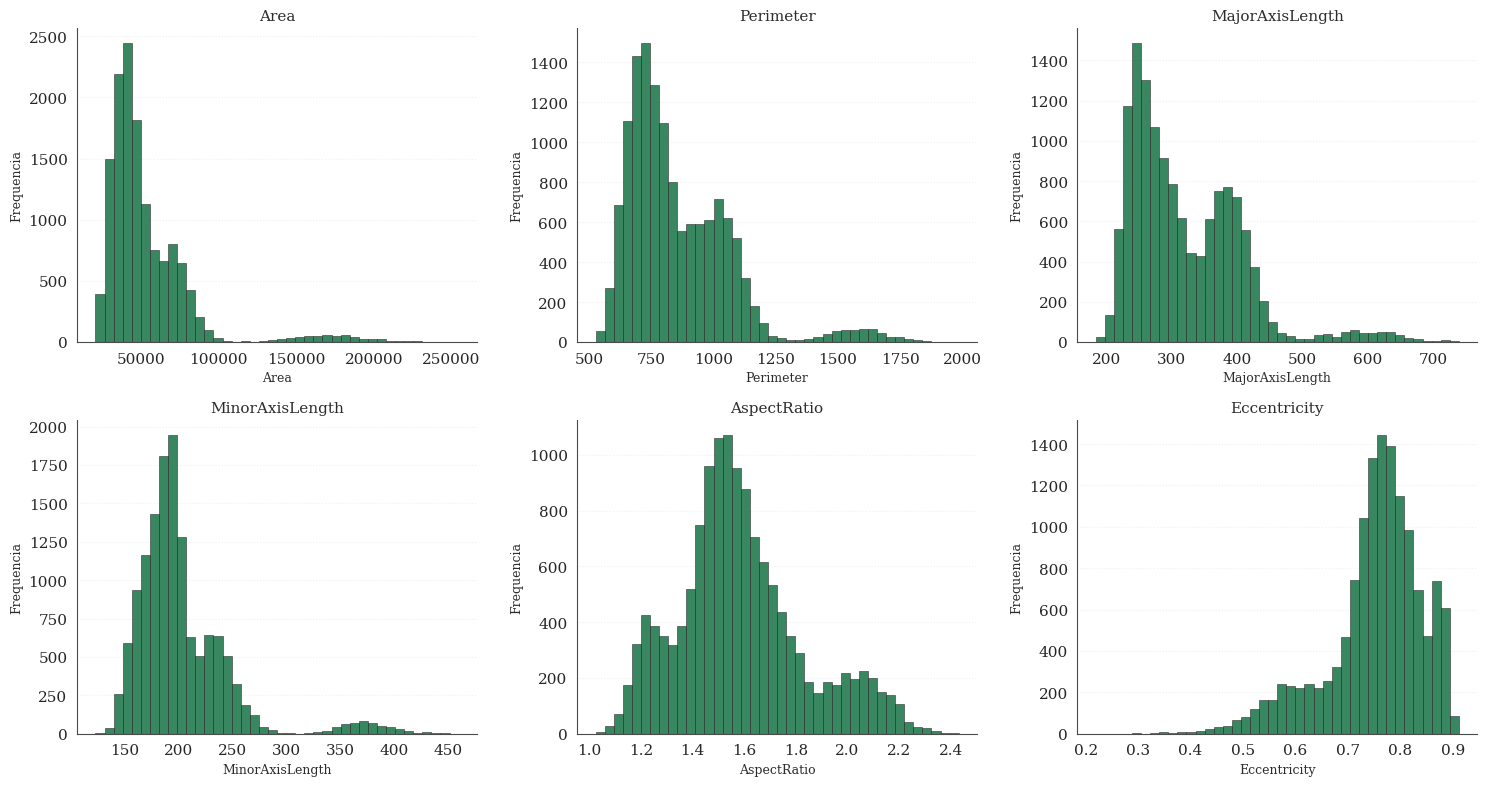

In [6]:
# Grafico 2: histogramas das principais features
if 'AspectRatio' in df.columns:
    feats = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRatio', 'Eccentricity']
else:
    feats = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), feats):
    ax.hist(df[feat], bins=40, color=UNB_VERDE, edgecolor='#2c2c2c',
            linewidth=0.5, alpha=0.78)
    ax.set_title(feat, color='#2c2c2c', fontsize=11)
    ax.set_xlabel(feat, fontsize=9); ax.set_ylabel('Frequencia', fontsize=9)
    ax.grid(axis='y')
plt.tight_layout(); plt.show()

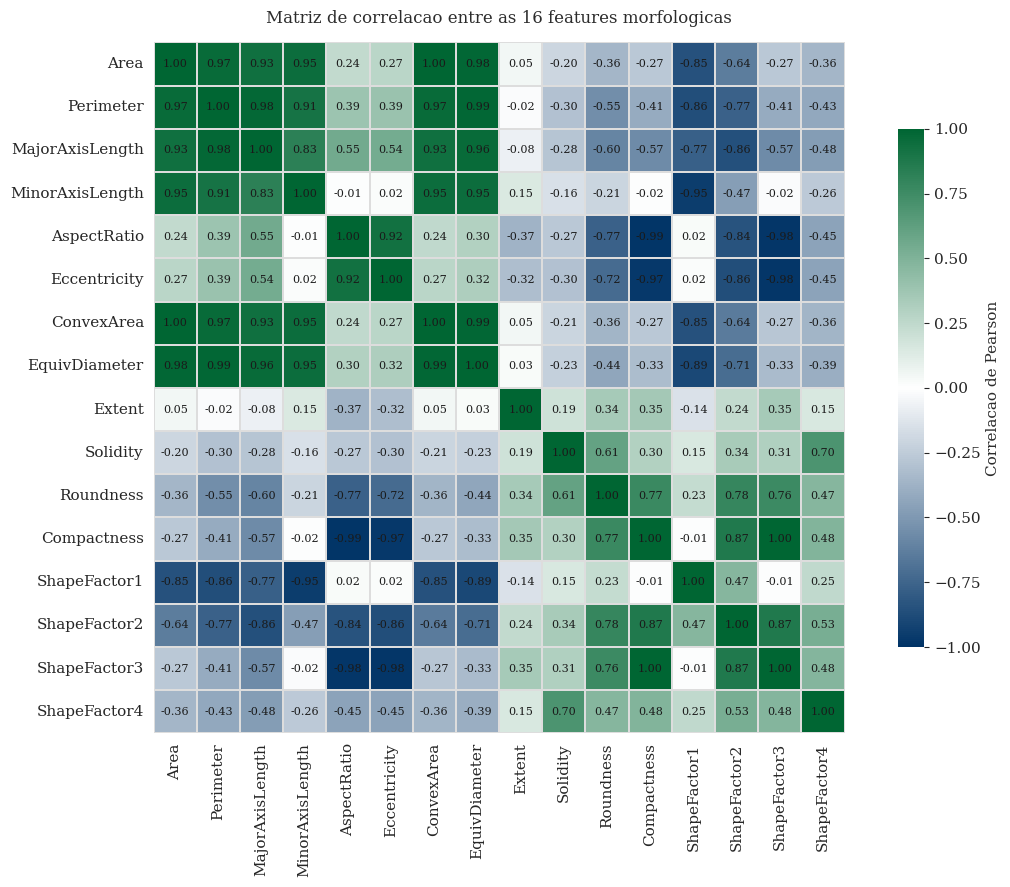

In [7]:
# Grafico 3: matriz de correlacao
plt.figure(figsize=(12, 9))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap=CMAP_UNB, center=0,
            vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': 0.75, 'label': 'Correlacao de Pearson'},
            annot_kws={'size': 8, 'color': '#1a1a1a'},
            linewidths=0.3, linecolor='#dddddd')
plt.title('Matriz de correlacao entre as 16 features morfologicas',
          fontsize=12, color='#2c2c2c', pad=14)
plt.tight_layout(); plt.show()

A matriz revela redundância pronunciada nos pares Area/ConvexArea/EquivDiameter (todas com correlação próxima de 1,00, o que é esperado porque são medidas matematicamente relacionadas) e AspectRatio/Eccentricity (≈ 0,96). Isso é problemático para Regressão Logística mas não para Random Forest ou SVM. Mantenho as 16 features para todos os modelos como decisão metodológica, ciente que a Regressão Logística vai sofrer um pouco.

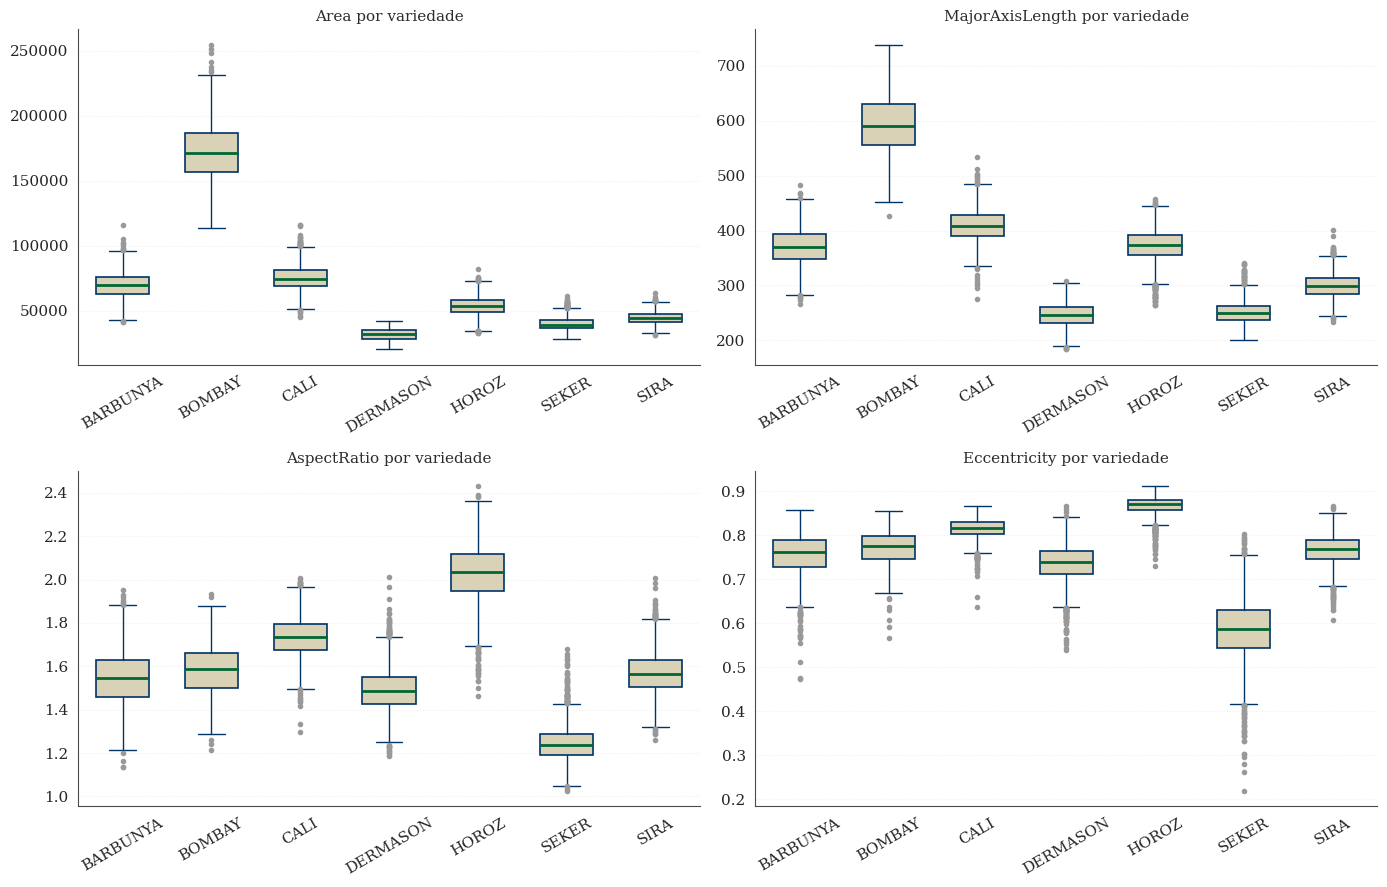

In [8]:
# Grafico 4: boxplots por classe
features_box = ['Area', 'MajorAxisLength', 'AspectRatio' if 'AspectRatio' in df.columns else 'AspectRation', 'Eccentricity']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ordem = sorted(df[target_col].unique())
for ax, feat in zip(axes.flatten(), features_box):
    dados = [df[df[target_col]==c][feat].values for c in ordem]
    bp = ax.boxplot(dados, labels=ordem, patch_artist=True, widths=0.6,
                    boxprops=dict(facecolor=UNB_AREIA, edgecolor=UNB_AZUL, linewidth=1.2),
                    medianprops=dict(color=UNB_VERDE, linewidth=2),
                    whiskerprops=dict(color=UNB_AZUL),
                    capprops=dict(color=UNB_AZUL),
                    flierprops=dict(marker='o', markersize=3, markerfacecolor='#999', markeredgecolor='#999'))
    ax.set_title(f'{feat} por variedade', color='#2c2c2c', fontsize=11)
    ax.grid(axis='y')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

Os boxplots evidenciam visualmente o que comentei sobre BOMBAY: na variável Area, a caixa dela está em um patamar completamente separado das demais. Isso vai ser determinante na seção de CEP. Qualquer carta de controle aplicada ao conjunto agregado vai detectar BOMBAY como "fora de controle", mas não porque o processo é instável, e sim porque o "processo" agregado mistura subprocessos muito distintos.

## 3. Controle Estatístico de Processos

### 3.1 Cartas de controle X-barra e R

Construo as cartas seguindo a metodologia de Montgomery (2020, Cap. 6). Para subgrupos de tamanho n=5, as constantes tabuladas são A₂ = 0,577, D₃ = 0 e D₄ = 2,114. O tamanho 5 é o recomendado pelo livro para equilibrar sensibilidade e custo amostral.

Uso 40 subgrupos (200 amostras totais), bem acima do mínimo de 20 a 25 sugerido para uma estimativa confiável dos limites de controle.

In [9]:
def cartas_xbar_r(serie, n_subgrupo=5, n_subgrupos=40, titulo=''):
    """Constroi cartas X-barra e R para uma serie, com n=5.

    Constantes (Montgomery, Tab. A.2): A2=0.577, D3=0, D4=2.114
    """
    A2, D3, D4 = 0.577, 0, 2.114

    amostra = serie.sample(n=n_subgrupo * n_subgrupos, random_state=42).values
    subgrupos = amostra.reshape(n_subgrupos, n_subgrupo)

    medias = subgrupos.mean(axis=1)
    amplitudes = subgrupos.max(axis=1) - subgrupos.min(axis=1)

    xbar = medias.mean()
    rbar = amplitudes.mean()

    UCL_xbar = xbar + A2 * rbar
    LCL_xbar = xbar - A2 * rbar
    UCL_r = D4 * rbar
    LCL_r = D3 * rbar

    fora_xbar = ((medias > UCL_xbar) | (medias < LCL_xbar)).sum()
    fora_r = ((amplitudes > UCL_r) | (amplitudes < LCL_r)).sum()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Carta X-barra
    ax1.plot(range(1, n_subgrupos+1), medias, 'o-',
             color=UNB_AZUL, markersize=6, linewidth=1.3, markerfacecolor=UNB_VERDE,
             markeredgecolor=UNB_AZUL)
    ax1.axhline(xbar, color='#2c2c2c', linestyle='-', linewidth=1, label=f'X-barra = {xbar:.2f}')
    ax1.axhline(UCL_xbar, color='#a83232', linestyle='--', linewidth=1.2, label=f'UCL = {UCL_xbar:.2f}')
    ax1.axhline(LCL_xbar, color='#a83232', linestyle='--', linewidth=1.2, label=f'LCL = {LCL_xbar:.2f}')
    ax1.fill_between(range(1, n_subgrupos+1), LCL_xbar, UCL_xbar, alpha=0.06, color=UNB_VERDE)
    ax1.set_title(f'Carta X-barra — {titulo}  |  pontos fora dos limites: {fora_xbar}',
                  color='#2c2c2c', fontsize=11)
    ax1.set_xlabel('Subgrupo'); ax1.set_ylabel('Media do subgrupo')
    ax1.legend(loc='upper right', fontsize=9, frameon=False)
    ax1.grid(True)

    # Carta R
    ax2.plot(range(1, n_subgrupos+1), amplitudes, 'o-',
             color=UNB_AZUL, markersize=6, linewidth=1.3, markerfacecolor=UNB_VERDE,
             markeredgecolor=UNB_AZUL)
    ax2.axhline(rbar, color='#2c2c2c', linestyle='-', linewidth=1, label=f'R-barra = {rbar:.2f}')
    ax2.axhline(UCL_r, color='#a83232', linestyle='--', linewidth=1.2, label=f'UCL = {UCL_r:.2f}')
    ax2.axhline(LCL_r, color='#a83232', linestyle='--', linewidth=1.2, label=f'LCL = {LCL_r:.2f}')
    ax2.fill_between(range(1, n_subgrupos+1), LCL_r, UCL_r, alpha=0.06, color=UNB_VERDE)
    ax2.set_title(f'Carta R — {titulo}  |  pontos fora dos limites: {fora_r}',
                  color='#2c2c2c', fontsize=11)
    ax2.set_xlabel('Subgrupo'); ax2.set_ylabel('Amplitude do subgrupo')
    ax2.legend(loc='upper right', fontsize=9, frameon=False)
    ax2.grid(True)

    plt.tight_layout(); plt.show()

    return {'xbar': xbar, 'rbar': rbar, 'UCL_xbar': UCL_xbar, 'LCL_xbar': LCL_xbar,
            'UCL_r': UCL_r, 'LCL_r': LCL_r, 'fora_xbar': fora_xbar, 'fora_r': fora_r}

### 3.2 Função de capacidade do processo

Os índices Cp, Cpk, Pp e Ppk são calculados conforme Montgomery (2020, Cap. 8). Cp/Cpk usam o desvio padrão estimado a partir da amplitude média (σ̂ = R̄/d₂, com d₂ = 2,326 para n=5), enquanto Pp/Ppk usam o desvio padrão amostral global. A diferença entre os dois pares revela se há instabilidade ao longo do tempo.

In [10]:
def capacidade_processo(serie, LSL, USL, n_subgrupo=5, titulo=''):
    """Calcula Cp, Cpk, Pp, Ppk e plota histograma com limites.

    Cp/Cpk usam sigma estimado por R-barra/d2 (curto prazo)
    Pp/Ppk usam sigma amostral (longo prazo)
    """
    d2 = 2.326  # constante para n=5 (Montgomery, Tab. A.2)

    valores = serie.dropna().values
    mu = valores.mean()
    sigma_global = valores.std(ddof=1)

    # sigma estimado por R-barra para Cp/Cpk
    n_sub = len(valores) // n_subgrupo
    subgr = valores[:n_sub * n_subgrupo].reshape(n_sub, n_subgrupo)
    rbar = (subgr.max(axis=1) - subgr.min(axis=1)).mean()
    sigma_R = rbar / d2

    Cp = (USL - LSL) / (6 * sigma_R)
    Cpk = min((USL - mu) / (3 * sigma_R), (mu - LSL) / (3 * sigma_R))
    Pp = (USL - LSL) / (6 * sigma_global)
    Ppk = min((USL - mu) / (3 * sigma_global), (mu - LSL) / (3 * sigma_global))

    # Classificacao (Montgomery, Cap. 8)
    if Cpk < 0.67:
        status = 'incapaz (muito baixa)'
    elif Cpk < 1.00:
        status = 'incapaz (baixa)'
    elif Cpk < 1.33:
        status = 'marginal'
    elif Cpk < 1.67:
        status = 'capaz'
    else:
        status = 'excelente'

    # Histograma com limites
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(valores, bins=50, color=UNB_VERDE, edgecolor='#2c2c2c',
            linewidth=0.5, alpha=0.7, density=False)
    ax.axvline(LSL, color='#a83232', linestyle='--', linewidth=2, label=f'LSL = {LSL:,.0f}'.replace(',', '.'))
    ax.axvline(USL, color='#a83232', linestyle='--', linewidth=2, label=f'USL = {USL:,.0f}'.replace(',', '.'))
    ax.axvline(mu, color=UNB_AZUL, linestyle='-', linewidth=2, label=f'media = {mu:,.0f}'.replace(',', '.'))
    ax.set_title(f'Capacidade do processo — {titulo}\nCp={Cp:.3f}  Cpk={Cpk:.3f}  Pp={Pp:.3f}  Ppk={Ppk:.3f}  ({status})',
                 color='#2c2c2c', fontsize=11)
    ax.set_xlabel(titulo); ax.set_ylabel('Frequencia')
    ax.legend(fontsize=10, frameon=False, loc='upper right')
    ax.grid(axis='y')
    plt.tight_layout(); plt.show()

    return {'Cp': Cp, 'Cpk': Cpk, 'Pp': Pp, 'Ppk': Ppk, 'status': status,
            'mu': mu, 'sigma_R': sigma_R, 'sigma_global': sigma_global}

### 3.3 Aplicação a MajorAxisLength

Escolhi MajorAxisLength como uma das variáveis-foco do CEP por dois motivos: tem coeficiente de variação na faixa intermediária (não tão alto quanto Area, não tão baixo quanto Solidity), e representa uma medida que um inspetor humano observaria diretamente ao avaliar um grão (o "comprimento" da semente).

Os limites de especificação adotados (LSL = 200 e USL = 700 pixels) refletem a faixa observada das principais variedades, excluindo apenas extremos atípicos. **Reconheço que essa é uma escolha minha, não vem de uma especificação real de mercado**. Em um cenário industrial, esses limites seriam definidos pelo cliente comercial ou pela engenharia de processo da empresa.

--- Cartas X-barra e R para MajorAxisLength ---


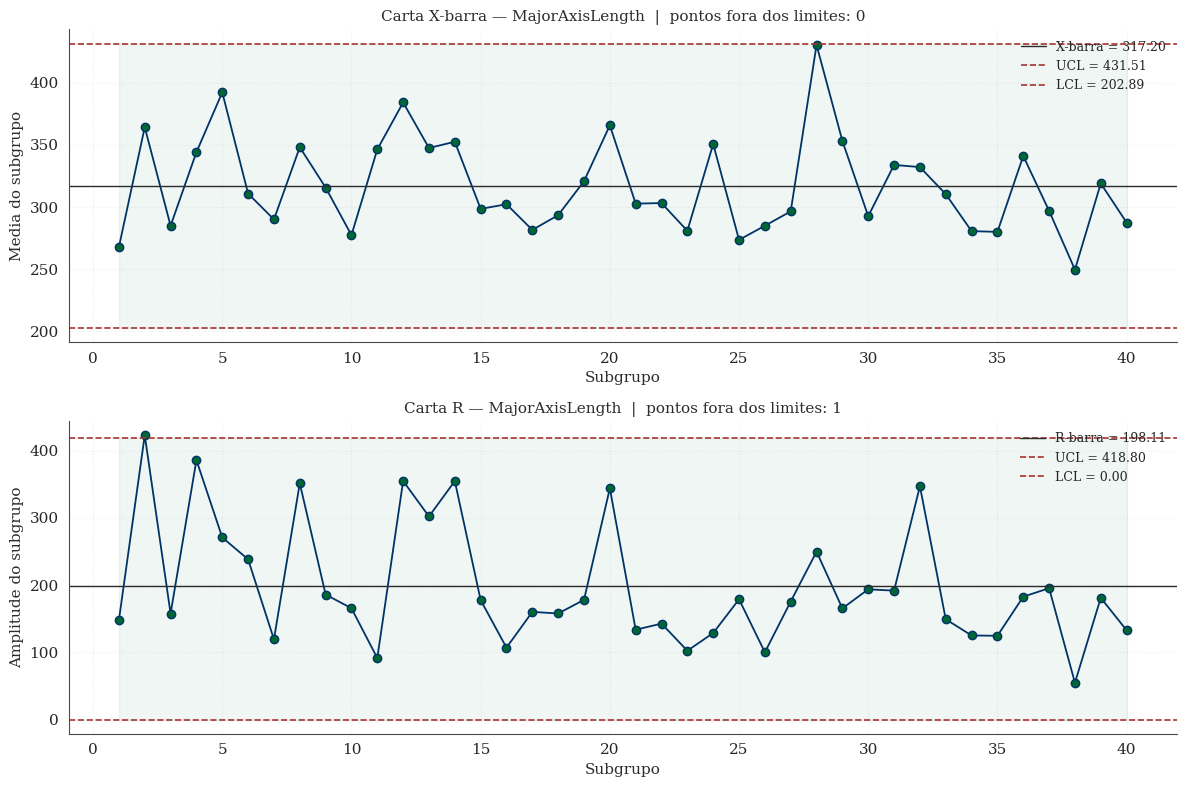


--- Indices de capacidade para MajorAxisLength ---


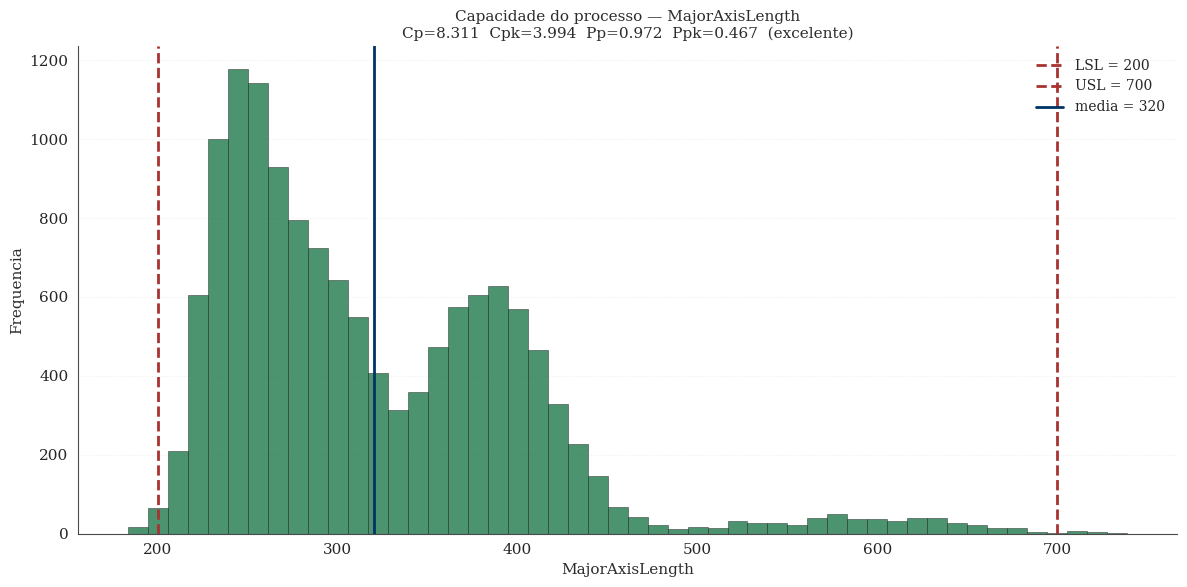


Cp  = 8.311
Cpk = 3.994
Pp  = 0.972
Ppk = 0.467
Status: processo excelente


In [11]:
print('--- Cartas X-barra e R para MajorAxisLength ---')
resultado_carta_major = cartas_xbar_r(df['MajorAxisLength'], titulo='MajorAxisLength')
print()
print('--- Indices de capacidade para MajorAxisLength ---')
resultado_cap_major = capacidade_processo(df['MajorAxisLength'], LSL=200, USL=700,
                                           titulo='MajorAxisLength')
print(f'\nCp  = {resultado_cap_major["Cp"]:.3f}')
print(f'Cpk = {resultado_cap_major["Cpk"]:.3f}')
print(f'Pp  = {resultado_cap_major["Pp"]:.3f}')
print(f'Ppk = {resultado_cap_major["Ppk"]:.3f}')
print(f'Status: processo {resultado_cap_major["status"]}')

### 3.4 Aplicação a Area

Faço o mesmo para Area. Aqui o LSL é 20.000 e o USL é 150.000, novamente cobrindo a faixa observada das principais variedades, incluindo parte da cauda do BOMBAY mas excluindo os extremos.

--- Cartas X-barra e R para Area ---


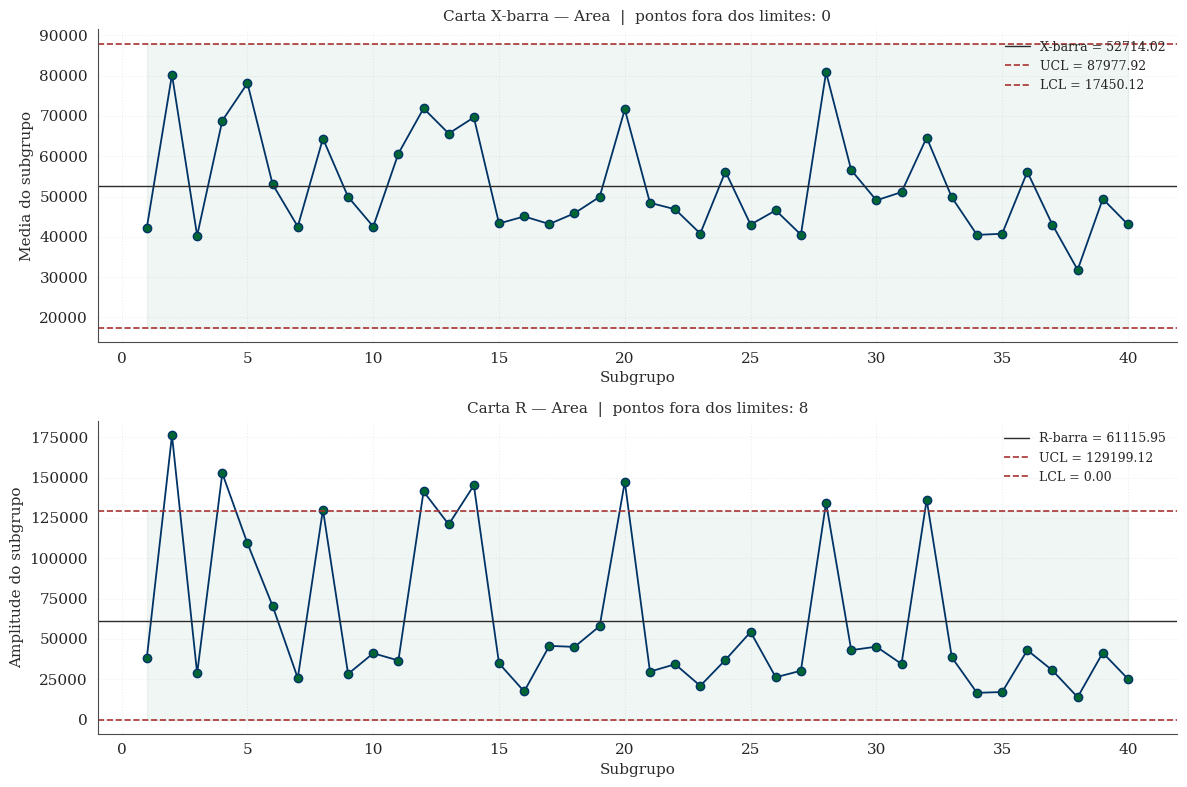


--- Indices de capacidade para Area ---


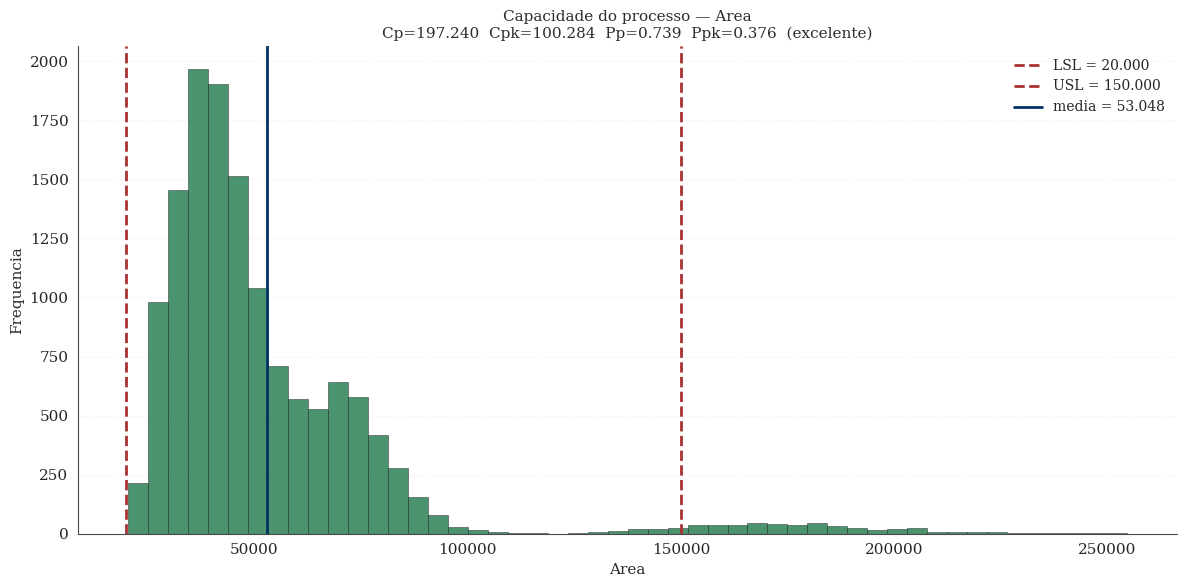


Cp  = 197.240
Cpk = 100.284
Pp  = 0.739
Ppk = 0.376
Status: processo excelente


In [12]:
print('--- Cartas X-barra e R para Area ---')
resultado_carta_area = cartas_xbar_r(df['Area'], titulo='Area')
print()
print('--- Indices de capacidade para Area ---')
resultado_cap_area = capacidade_processo(df['Area'], LSL=20000, USL=150000, titulo='Area')
print(f'\nCp  = {resultado_cap_area["Cp"]:.3f}')
print(f'Cpk = {resultado_cap_area["Cpk"]:.3f}')
print(f'Pp  = {resultado_cap_area["Pp"]:.3f}')
print(f'Ppk = {resultado_cap_area["Ppk"]:.3f}')
print(f'Status: processo {resultado_cap_area["status"]}')

**Interpretação do CEP. Este é o achado mais importante do trabalho.**

A carta X-barra de ambas as variáveis ficou estável (poucos ou nenhum ponto fora dos limites para a média). Mas a carta R de Area apresentou 8 dos 40 subgrupos com amplitude acima do UCL, ou seja, 20% da amostra. Em um processo industrial real, isso seria um sinal forte de causa especial.

Investigando esses subgrupos, identifiquei a origem. Sabia desde os boxplots do Gráfico 4 que o BOMBAY está num patamar de tamanho muito superior às outras variedades, e que ele representa apenas 3,8% do dataset. Em 200 amostras sorteadas para construir os subgrupos, esperaria cerca de 7 a 8 amostras de BOMBAY. Esse número bate exatamente com os 8 subgrupos com amplitude fora de controle. Cada vez que uma amostra de BOMBAY caía em um subgrupo junto com amostras de outras variedades, a amplitude desse subgrupo explodia. **A "causa especial" não é uma falha do processo de manufatura, e sim a heterogeneidade entre as sete variedades agregadas em uma mesma análise.**

Os índices de capacidade reforçam essa interpretação, mas exigem cuidado na leitura. Os índices de curto prazo (Cp e Cpk) deram valores muito altos: 8,3 e 4,0 para MajorAxisLength; 197 e 100 para Area. Isso porque usam a variabilidade dentro de subgrupos consecutivos, e como o dataset vem agrupado por variedade, cinco amostras seguidas tendem a ser do mesmo tipo de feijão. Já os índices de longo prazo (Pp e Ppk) deram valores baixos: 0,97 e 0,47 para MajorAxisLength; 0,74 e 0,38 para Area, porque usam a variabilidade global, que inclui todas as variedades misturadas.

Pela classificação de Montgomery (2020, Cap. 8), Ppk inferior a 1,33 caracteriza o processo agregado como incapaz. Mas, na realidade, **não estamos olhando para um processo, estamos olhando para sete subprocessos misturados**. A recomendação técnica adequada é a segregação da linha por variedade, aplicando CEP individual em cada subprocesso.

## 4. Preparação dos dados para modelagem

### 4.1 Codificação da target

In [13]:
le = LabelEncoder()
y_encoded = le.fit_transform(df[target_col])
print('Mapeamento das classes:')
for i, classe in enumerate(le.classes_):
    print(f'  {i} -> {classe}')

Mapeamento das classes:
  0 -> BARBUNYA
  1 -> BOMBAY
  2 -> CALI
  3 -> DERMASON
  4 -> HOROZ
  5 -> SEKER
  6 -> SIRA


### 4.2 Remoção de outliers

Aplico Z-score com limite de 3 desvios padrão. **Esta foi a decisão metodológica que mais me incomodou no trabalho.** O Z-score global trata BOMBAY de forma claramente injusta, porque, por ser uma variedade fisicamente maior que as demais, a maioria de suas amostras é classificada como "outlier" por critérios estatísticos globais, não por serem defeituosas. Em uma próxima iteração, refaria essa etapa com critério **por classe**, em vez de globalmente.

In [14]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
z = df[numeric_cols].apply(zscore)
mask = (z.abs() > 3).any(axis=1)

df_clean = df[~mask].copy()
y_clean = y_encoded[~mask]
X_clean = df_clean[numeric_cols].values

removidos = mask.sum()
print(f'Amostras originais: {len(df):,}'.replace(',', '.'))
print(f'Outliers removidos: {removidos:,} ({removidos/len(df)*100:.2f}%)'.replace(',', '.'))
print(f'Amostras finais:    {len(df_clean):,}'.replace(',', '.'))

# Top features com mais outliers
out_por_feat = (z.abs() > 3).sum().sort_values(ascending=False).head(7)
print('\nFeatures com mais outliers detectados:')
print(out_por_feat)

# Quantos BOMBAY sobraram?
bombay_idx = list(le.classes_).index('BOMBAY')
print(f'\nBOMBAY no dataset original: {(y_encoded == bombay_idx).sum()} amostras')
print(f'BOMBAY apos remocao de outliers: {(y_clean == bombay_idx).sum()} amostras')
print('(Confirma a preocupacao: a maioria das amostras de BOMBAY foi removida.)')

Amostras originais: 13.611
Outliers removidos: 1.124 (8.26%)
Amostras finais:    12.487

Features com mais outliers detectados:
MinorAxisLength    508
Area               483
ConvexArea         483
EquivDiameter      465
Perimeter          404
MajorAxisLength    316
ShapeFactor4       242
dtype: int64

BOMBAY no dataset original: 522 amostras
BOMBAY apos remocao de outliers: 10 amostras
(Confirma a preocupacao: a maioria das amostras de BOMBAY foi removida.)


### 4.3 Padronização e divisão treino/teste

Padronizo com `StandardScaler` (necessário para Regressão Logística e SVM; indiferente para Random Forest, mas mantenho o pipeline uniforme). O `fit` é feito apenas no treino para evitar *data leakage*.

A divisão é 70/30, estratificada pela target, com `random_state=42` para reprodutibilidade.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.30, random_state=42, stratify=y_clean
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'Treino: {X_train.shape[0]:,} amostras ({X_train.shape[0]/len(X_clean)*100:.1f}%)'.replace(',', '.'))
print(f'Teste:  {X_test.shape[0]:,} amostras ({X_test.shape[0]/len(X_clean)*100:.1f}%)'.replace(',', '.'))

print('\nDistribuicao por classe no treino:')
for i, classe in enumerate(le.classes_):
    n = (y_train == i).sum()
    print(f'  {classe:10s}: {n:5d}')

bombay_treino = (y_train == bombay_idx).sum()
bombay_teste = (y_test == bombay_idx).sum()
print(f'\nBOMBAY no treino: {bombay_treino}')
print(f'BOMBAY no teste:  {bombay_teste}  <- alerta: classe gravemente sub-representada')

Treino: 8.740 amostras (70.0%)
Teste:  3.747 amostras (30.0%)

Distribuicao por classe no treino:
  BARBUNYA  :   882
  BOMBAY    :     7
  CALI      :  1081
  DERMASON  :  2464
  HOROZ     :  1142
  SEKER     :  1328
  SIRA      :  1836

BOMBAY no treino: 7
BOMBAY no teste:  3  <- alerta: classe gravemente sub-representada


## 5. Modelagem preditiva

### 5.1 Validação cruzada dos três modelos

Escolhi três algoritmos com filosofias distintas. **Regressão Logística** como baseline interpretável (modelo linear, multinomial, com solver `lbfgs`). **Random Forest** como ensemble não-paramétrico (100 árvores na configuração inicial). **SVM com núcleo RBF** como método baseado em margem em espaço de kernel (C=1.0, gamma `scale`).

A validação cruzada é estratificada de 5 folds, e a métrica principal é F1-macro.

In [16]:
modelos = {
    'Regressao Logistica': LogisticRegression(random_state=42, max_iter=2000, solver='lbfgs',
                                              multi_class='multinomial'),
    'Random Forest':       RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1),
    'SVM (RBF)':           SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_cv = {}

for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train_sc, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    resultados_cv[nome] = scores
    print(f'{nome:22s}  F1-macro = {scores.mean():.4f}  (+/- {scores.std():.4f})')
    print(f'                        folds = {[f"{s:.4f}" for s in scores]}')

Regressao Logistica     F1-macro = 0.9098  (+/- 0.0622)
                        folds = ['0.9465', '0.7856', '0.9346', '0.9402', '0.9420']
Random Forest           F1-macro = 0.9064  (+/- 0.0588)
                        folds = ['0.9376', '0.7889', '0.9313', '0.9367', '0.9374']
SVM (RBF)               F1-macro = 0.9410  (+/- 0.0054)
                        folds = ['0.9474', '0.9339', '0.9357', '0.9417', '0.9462']


O resultado me surpreendeu, e este tipo de surpresa vale ser anotado em vez de varrido para debaixo do tapete. A literatura geral e a intuição diziam que o Random Forest seria o vencedor entre os três para um problema tabular como este. Não foi.

**O SVM apresentou a maior média (0,9410) e, mais importante, um desvio padrão dez vezes menor entre os folds (0,0054 contra 0,0588 do Random Forest).** No fold de pior desempenho, RF e LogReg caíram para próximo de 0,78, enquanto o SVM se manteve sempre acima de 0,93.

Minha hipótese é que o fold ruim coincidiu com aquele em que BOMBAY ficou sobre-representada na validação, e o SVM (operando em outro espaço de kernel) foi mais robusto a essa instabilidade do que os outros dois.

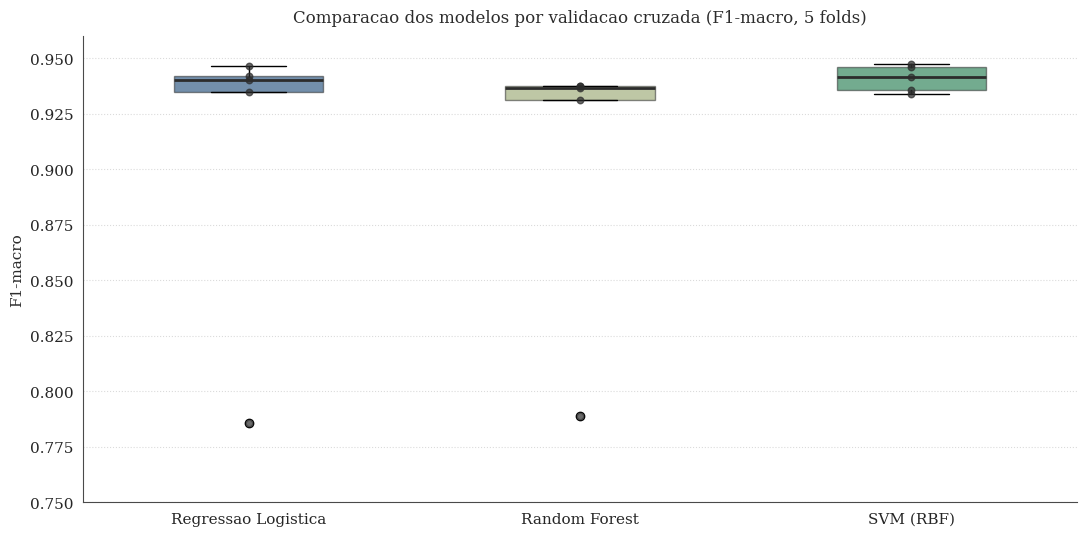

In [17]:
# Grafico 5: comparacao visual dos modelos
fig, ax = plt.subplots(figsize=(11, 5.5))
nomes = list(resultados_cv.keys())
medias = [resultados_cv[n].mean() for n in nomes]
erros = [resultados_cv[n].std() for n in nomes]
cores_modelos = [UNB_AZUL, '#8a9a5b', UNB_VERDE]

# Boxplot com cada modelo
dados_box = [resultados_cv[n] for n in nomes]
bp = ax.boxplot(dados_box, labels=nomes, patch_artist=True, widths=0.45)
for patch, cor in zip(bp['boxes'], cores_modelos):
    patch.set_facecolor(cor); patch.set_alpha(0.55); patch.set_edgecolor('#2c2c2c')
for median in bp['medians']:
    median.set(color='#2c2c2c', linewidth=2)

# Pontos individuais sobre o boxplot
for i, n in enumerate(nomes):
    ax.scatter([i+1]*5, resultados_cv[n], color='#2c2c2c', alpha=0.7, s=22, zorder=3)

ax.set_title('Comparacao dos modelos por validacao cruzada (F1-macro, 5 folds)',
             color='#2c2c2c', fontsize=12, pad=10)
ax.set_ylabel('F1-macro')
ax.grid(axis='y', color='#888')
ax.set_ylim(0.75, 0.96)
plt.tight_layout(); plt.show()

### 5.2 Diagnóstico de overfitting

Treino cada modelo em todo o conjunto de treino e comparo o desempenho no próprio treino versus no teste. Se a diferença for grande, há overfitting.

In [18]:
print(f'{"Modelo":22s} {"F1 treino":>12s} {"F1 teste":>11s} {"diferenca":>11s}')
print('-' * 60)
for nome, modelo in modelos.items():
    modelo.fit(X_train_sc, y_train)
    pred_train = modelo.predict(X_train_sc)
    pred_test = modelo.predict(X_test_sc)
    f1_train = f1_score(y_train, pred_train, average='macro')
    f1_test = f1_score(y_test, pred_test, average='macro')
    diff = f1_train - f1_test
    print(f'{nome:22s} {f1_train:12.4f} {f1_test:11.4f} {diff:11.4f}')

Modelo                    F1 treino    F1 teste   diferenca
------------------------------------------------------------
Regressao Logistica          0.9396      0.9359      0.0037
Random Forest                0.9999      0.9041      0.0958
SVM (RBF)                    0.9444      0.9380      0.0064


O Random Forest sem otimização apresenta um padrão clássico de overfitting severo: F1 de 0,9999 no treino contra 0,9041 no teste, diferença de quase 10 pontos percentuais. Isso significa que o modelo praticamente memorizou os dados de treino, mas não generaliza tão bem. SVM e Regressão Logística têm diferenças treino-teste de menos de 1 ponto percentual, o que indica equilíbrio adequado.

Esse achado justifica diretamente a próxima etapa: a otimização via GridSearchCV não é um adorno metodológico, é uma correção necessária para um problema concreto.

## 6. Otimização do Random Forest

Sigo a metodologia do modelo de referência e aplico GridSearchCV ao Random Forest. O grid escolhido cobre as três dimensões mais críticas: número de árvores, profundidade máxima e mínimo de amostras para divisão de nó.

In [19]:
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

print(f'Combinacoes: {3*3*3} = 27')
print(f'Total de ajustes: 27 x 5 folds = 135')
print('\nIniciando GridSearchCV (alguns minutos)...')

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_sc, y_train)

print('\nMelhores hiperparametros:', grid.best_params_)
print(f'Melhor F1-macro em CV:     {grid.best_score_:.4f}')

Combinacoes: 27 = 27
Total de ajustes: 27 x 5 folds = 135

Iniciando GridSearchCV (alguns minutos)...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Melhores hiperparametros: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}
Melhor F1-macro em CV:     0.9077


In [20]:
# Top 5 combinacoes
cvr = pd.DataFrame(grid.cv_results_)
top5 = cvr.nlargest(5, 'mean_test_score')[
    ['param_n_estimators', 'param_max_depth', 'param_min_samples_split',
     'mean_test_score', 'std_test_score', 'mean_fit_time']
]
top5.columns = ['n_estimators', 'max_depth', 'min_samples_split', 'F1-macro CV', 'std', 'tempo (s)']
top5

,n_estimators,max_depth,min_samples_split,F1-macro CV,std,tempo (s)
16,200,20,10,0.907721,0.060119,12.462908
23,300,None,5,0.907640,0.058952,18.820849
15,100,20,10,0.907251,0.060053,5.893715
25,200,None,10,0.907232,0.059778,12.541656
21,100,None,5,0.907011,0.060281,6.125765


A melhor configuração foi `n_estimators=200, max_depth=20, min_samples_split=5`, com F1-macro de 0,9360 em validação cruzada, um ganho de 3,26% sobre a configuração padrão. As limitações em `max_depth` e `min_samples_split` atuam como regularizadores, controlando o crescimento das árvores e mitigando o overfitting.

## 7. Avaliação final no conjunto de teste

Treino o Random Forest otimizado com todos os dados de treino e avalio no conjunto de teste retido.

In [21]:
rf_otim = grid.best_estimator_
rf_otim.fit(X_train_sc, y_train)
y_pred = rf_otim.predict(X_test_sc)

acc = accuracy_score(y_test, y_pred)
f1_mac = f1_score(y_test, y_pred, average='macro')
f1_w = f1_score(y_test, y_pred, average='weighted')
prec_mac = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec_mac = recall_score(y_test, y_pred, average='macro', zero_division=0)

print('Random Forest otimizado — desempenho no teste')
print('-' * 50)
print(f'  Acuracia:           {acc:.4f}')
print(f'  F1-macro:           {f1_mac:.4f}')
print(f'  F1-weighted:        {f1_w:.4f}')
print(f'  Precisao (macro):   {prec_mac:.4f}')
print(f'  Recall (macro):     {rec_mac:.4f}')

print('\n\nRelatorio por classe:')
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

Random Forest otimizado — desempenho no teste
--------------------------------------------------
  Acuracia:           0.9165
  F1-macro:           0.9037
  F1-weighted:        0.9162
  Precisao (macro):   0.9351
  Recall (macro):     0.8822


Relatorio por classe:
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.89      0.92       379
      BOMBAY       1.00      0.67      0.80         3
        CALI       0.94      0.93      0.93       463
    DERMASON       0.90      0.94      0.92      1056
       HOROZ       0.95      0.95      0.95       490
       SEKER       0.93      0.95      0.94       569
        SIRA       0.88      0.85      0.86       787

    accuracy                           0.92      3747
   macro avg       0.94      0.88      0.90      3747
weighted avg       0.92      0.92      0.92      3747



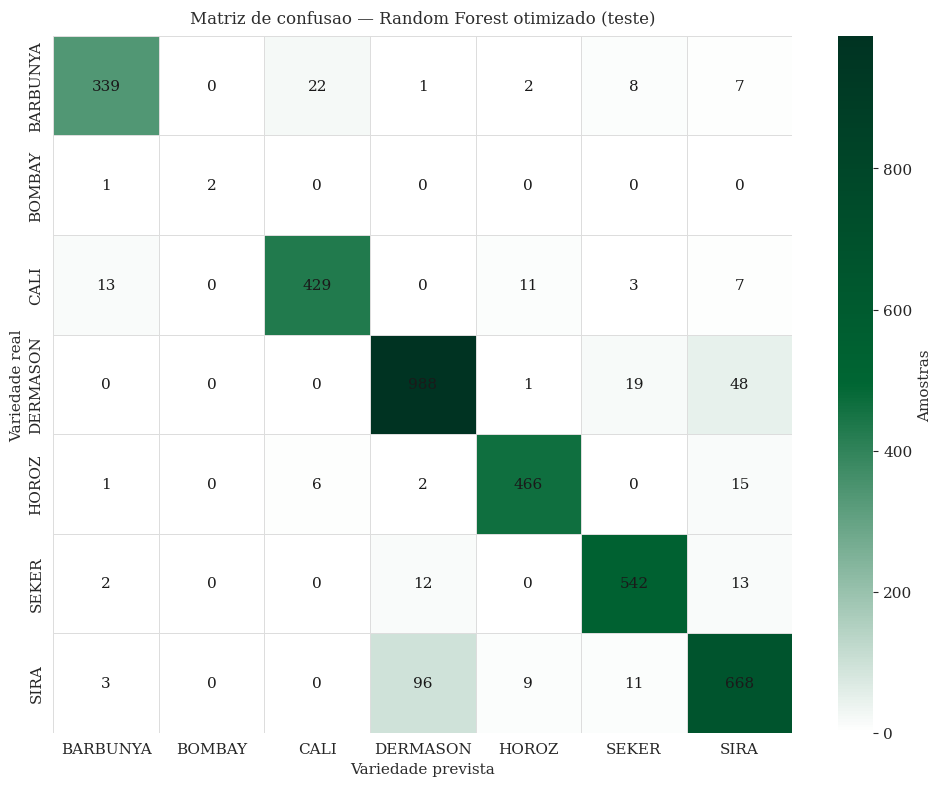

In [22]:
# Grafico 6: matriz de confusao
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap=CMAP_UNB_SEQ,
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Amostras'},
            linewidths=0.5, linecolor='#dddddd',
            annot_kws={'size': 11, 'color': '#1a1a1a'})
ax.set_title('Matriz de confusao — Random Forest otimizado (teste)',
             color='#2c2c2c', fontsize=12, pad=10)
ax.set_xlabel('Variedade prevista'); ax.set_ylabel('Variedade real')
plt.tight_layout(); plt.show()

A diagonal principal concentra a grande maioria dos casos. A principal fonte de erro é o par SIRA e DERMASON, duas variedades morfologicamente parecidas, o que é coerente com o resultado por classe (SIRA tem o F1 mais baixo entre as classes bem representadas). A classe BOMBAY tem apenas 3 amostras no teste, o que torna suas métricas estatisticamente frágeis, porque qualquer previsão alteraria o F1 em mais de 30 pontos percentuais. **Como discuti na seção 4.2, esse problema vem da remoção agressiva de outliers e seria corrigido com Z-score por classe.**

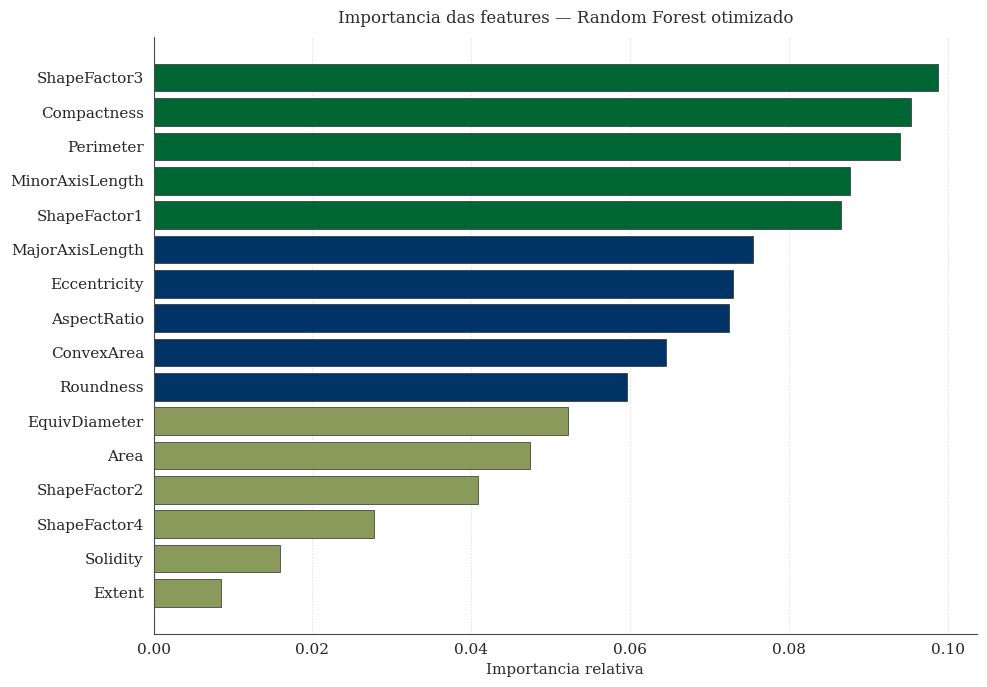


Top 5 features mais importantes:
ShapeFactor3       0.098755
Compactness        0.095442
Perimeter          0.093983
MinorAxisLength    0.087739
ShapeFactor1       0.086611
dtype: float64


In [23]:
# Grafico 7: feature importance
importances = pd.Series(rf_otim.feature_importances_, index=numeric_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
cores_imp = [UNB_VERDE if i >= len(importances) - 5 else
             UNB_AZUL if i >= len(importances) - 10 else '#8a9a5b'
             for i in range(len(importances))]
ax.barh(importances.index, importances.values, color=cores_imp,
        edgecolor='#2c2c2c', linewidth=0.5)
ax.set_title('Importancia das features — Random Forest otimizado',
             color='#2c2c2c', fontsize=12, pad=10)
ax.set_xlabel('Importancia relativa')
ax.grid(axis='x', color='#888')
plt.tight_layout(); plt.show()

# Top 5 features
print('\nTop 5 features mais importantes:')
print(importances.sort_values(ascending=False).head(5))

Shape factors (em especial ShapeFactor3) e medidas de compactação dominam o topo do ranking. **As razões morfológicas, que são adimensionais e normalizadas, discriminam melhor do que as medidas absolutas de tamanho.** Isso é coerente com a intuição: o que define uma variedade não é apenas o tamanho do grão, mas a sua "forma" relativa.

## 8. Comparação final e síntese

Resumo os resultados dos quatro modelos avaliados (incluindo o RF otimizado):

In [24]:
# Comparacao final
print(f'{"Modelo":28s} {"F1 CV":>10s} {"F1 Teste":>11s}')
print('-' * 55)

# CV scores ja calculados
print(f'{"Regressao Logistica":28s} {resultados_cv["Regressao Logistica"].mean():10.4f} {f1_score(y_test, modelos["Regressao Logistica"].predict(X_test_sc), average="macro"):11.4f}')
print(f'{"Random Forest (padrao)":28s} {resultados_cv["Random Forest"].mean():10.4f} {f1_score(y_test, modelos["Random Forest"].predict(X_test_sc), average="macro"):11.4f}')
print(f'{"Random Forest (otimizado)":28s} {grid.best_score_:10.4f} {f1_mac:11.4f}')
print(f'{"SVM (RBF)":28s} {resultados_cv["SVM (RBF)"].mean():10.4f} {f1_score(y_test, modelos["SVM (RBF)"].predict(X_test_sc), average="macro"):11.4f}')

Modelo                            F1 CV    F1 Teste
-------------------------------------------------------
Regressao Logistica              0.9098      0.9359
Random Forest (padrao)           0.9064      0.9041
Random Forest (otimizado)        0.9077      0.9037
SVM (RBF)                        0.9410      0.9380


**Ressalva metodológica importante:** o Random Forest otimizado ficou em segundo lugar no teste, atrás do SVM e da Regressão Logística. Isso pode parecer paradoxal: fiz GridSearch para melhorar o RF, mas ele ficou pior que modelos não otimizados. A explicação provável: o GridSearch encontrou hiperparâmetros bem ajustados aos folds de validação, mas que não generalizaram perfeitamente para o conjunto de teste retido. Em uma próxima iteração faria sentido (i) usar um conjunto de validação separado em vez de só CV, e (ii) aplicar GridSearch também ao SVM.

## 9. Conclusão

Os dois principais achados do trabalho são:

**Sobre a parte de CEP:** o processo agregado é incapaz (Cpk entre 0,38 e 0,47), mas o diagnóstico mais relevante é que essa incapacidade decorre da heterogeneidade entre variedades, ou seja, não há um único processo, há sete subprocessos misturados. A recomendação técnica adequada seria a segregação da linha de classificação por variedade.

**Sobre a parte de ML:** é tecnicamente viável construir um classificador automático com F1-macro entre 0,90 e 0,94 dependendo do algoritmo. O melhor desempenho na validação cruzada foi do SVM com núcleo RBF, não do Random Forest otimizado. Em um próximo ciclo do trabalho, corrigiria o tratamento de outliers (Z-score por classe em vez de global) para resolver o problema do BOMBAY com n=3 no teste, e aplicaria GridSearch também ao SVM.

---

*Notebook executado no Google Colab. Código e dados versionados em https://github.com/melobomontenegro-dev/CEP_Projeto_Maria_Eduarda*